# 03_exploratory_analysis

**Role:** Establish baseline network properties.

**Tasks:**
- Calculate degree distribution
- Compute clustering coefficient
- Measure density
- Analyze connected components
- Approximate shortest path analysis

**Outputs:**
- Histograms
- Summary statistics

**Evaluation Focus:** Core analysis completeness (35% of total value)


---
## 1) Load Network

Import the network using the utility function created in the previous step.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import random

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

sys.path.append("../src")
from graph_utils import load_youtube_graph

G = load_youtube_graph()
print(f"Loaded Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loading graph from ../data/raw/com-youtube.ungraph.txt...


Loaded Graph: 1,134,890 nodes, 2,987,624 edges


---
## 2) Network Density

Density measures the ratio of existing edges to all possible edges.

In [2]:
density = nx.density(G)
print(f"Network Density: {density:.6e}")

Network Density: 4.639261e-06


---
## 3) Connected Components

Identify distinct connected subgraphs and extract the Largest Connected Component (LCC) for subsequent structural analysis.

In [3]:
cc_count = nx.number_connected_components(G)
print(f"Total Connected Components: {cc_count:,}")

# Extract Largest Connected Component (LCC)
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print(f"LCC Nodes: {G_lcc.number_of_nodes():,} ({G_lcc.number_of_nodes()/G.number_of_nodes():.2%})")
print(f"LCC Edges: {G_lcc.number_of_edges():,} ({G_lcc.number_of_edges()/G.number_of_edges():.2%})")

Total Connected Components: 1


LCC Nodes: 1,134,890 (100.00%)


LCC Edges: 2,987,624 (100.00%)


---
## 4) Degree Distribution

Calculate node degrees and plot the distribution on a log-log scale to inspect scale-free properties.

Average Degree: 5.27


Maximum Degree: 28,754


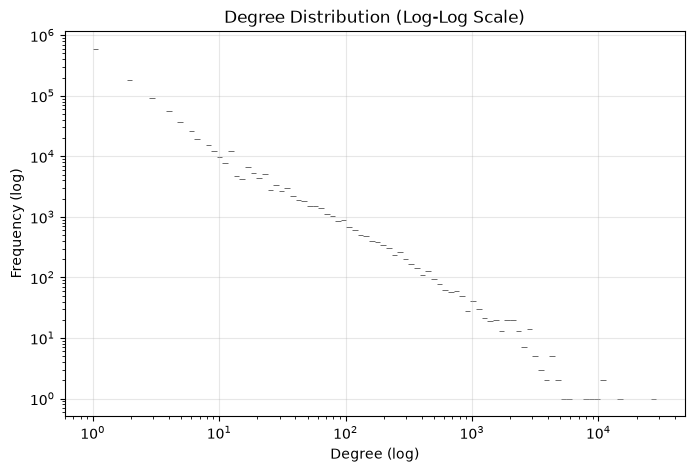

In [4]:
degrees = [d for n, d in G.degree()]

print(f"Average Degree: {np.mean(degrees):.2f}")
print(f"Maximum Degree: {np.max(degrees):,}")

plt.figure(figsize=(8, 5))
sns.histplot(degrees, bins=100, log_scale=(True, True), color="#2A75D3")
plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.grid(True, alpha=0.3)
plt.show()

---
## 5) Clustering Coefficient

Due to the scale of the dataset (~1.1M nodes), calculating exact global clustering is computationally prohibitive. We approximate this metric using a random sample of nodes.

In [5]:
random.seed(42)
sample_size = 10000
sampled_nodes = random.sample(list(G.nodes()), sample_size)

approx_clustering = nx.average_clustering(G, nodes=sampled_nodes)
print(f"Approximate Average Clustering (n={sample_size}): {approx_clustering:.4f}")

Approximate Average Clustering (n=10000): 0.0780


---
## 6) Shortest Path Analysis

Exact average shortest path computation is $O(VE)$ and infeasible here. We approximate the average path length by sampling node pairs within the LCC.

In [6]:
num_pairs = 1000
path_lengths = []
lcc_nodes_list = list(G_lcc.nodes())

for _ in range(num_pairs):
    u, v = random.sample(lcc_nodes_list, 2)
    try:
        length = nx.shortest_path_length(G_lcc, source=u, target=v)
        path_lengths.append(length)
    except nx.NetworkXNoPath:
        continue

approx_avg_path = np.mean(path_lengths)
print(f"Approximate Average Path Length (pairs={num_pairs}): {approx_avg_path:.2f}")

Approximate Average Path Length (pairs=1000): 5.29


> **Interpretation (Network Science Perspective):**
> 1. **Observation**: The network exhibits a heavily right-skewed degree distribution and an exceptionally large Largest Connected Component (LCC), indicating that the vast majority of users are reachable within a single unified structure.
> 2. **Structural Interpretation**: The skewed distribution is inconsistent with a purely random (ER) formation. Furthermore, the relatively high clustering coefficient—despite the large scale—suggests a tendency toward local triadic closure (e.g., friends of friends are likely friends).
> 3. **Next Step**: To contextualize these empirical metrics, we benchmark them against theoretically generated Erdos-Renyi (ER), Barabasi-Albert (BA), and Watts-Strogatz (WS) null models.